**Maternal Health Care Project**

**Importing dependencies**

In [1]:
import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.filterwarnings("ignore")

from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# ML Libraries
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix

**Data Collection**

In [2]:
# Loading the dataset into a pandas dataframe
m_df = pd.read_csv("Maternal Health Risk Data Set.csv")

In [3]:
# Getting the first 5 rows of the dataset
m_df.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [4]:
# Getting the number of rows and columns of the dataset
m_df.shape

(1014, 7)

In [5]:
# Getting some information about the dataset
m_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


In [6]:
# Checking for missing values in the dataset
m_df.isnull().sum()

Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

In [7]:
# Getting the summary statistics of the dataset
m_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1014.0,29.871795,13.474386,10.0,19.0,26.0,39.0,70.0
SystolicBP,1014.0,113.198225,18.403913,70.0,100.0,120.0,120.0,160.0
DiastolicBP,1014.0,76.460552,13.885796,49.0,65.0,80.0,90.0,100.0
BS,1014.0,8.725986,3.293532,6.0,6.9,7.5,8.0,19.0
BodyTemp,1014.0,98.665089,1.371384,98.0,98.0,98.0,98.0,103.0
HeartRate,1014.0,74.301775,8.088702,7.0,70.0,76.0,80.0,90.0


In [8]:
# Checking for duplicate rows in the dataset
m_df.duplicated().sum()

562

In [9]:
# Checking the distribution of the target variable
m_df["RiskLevel"].value_counts()

RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64

**Data Visualization**

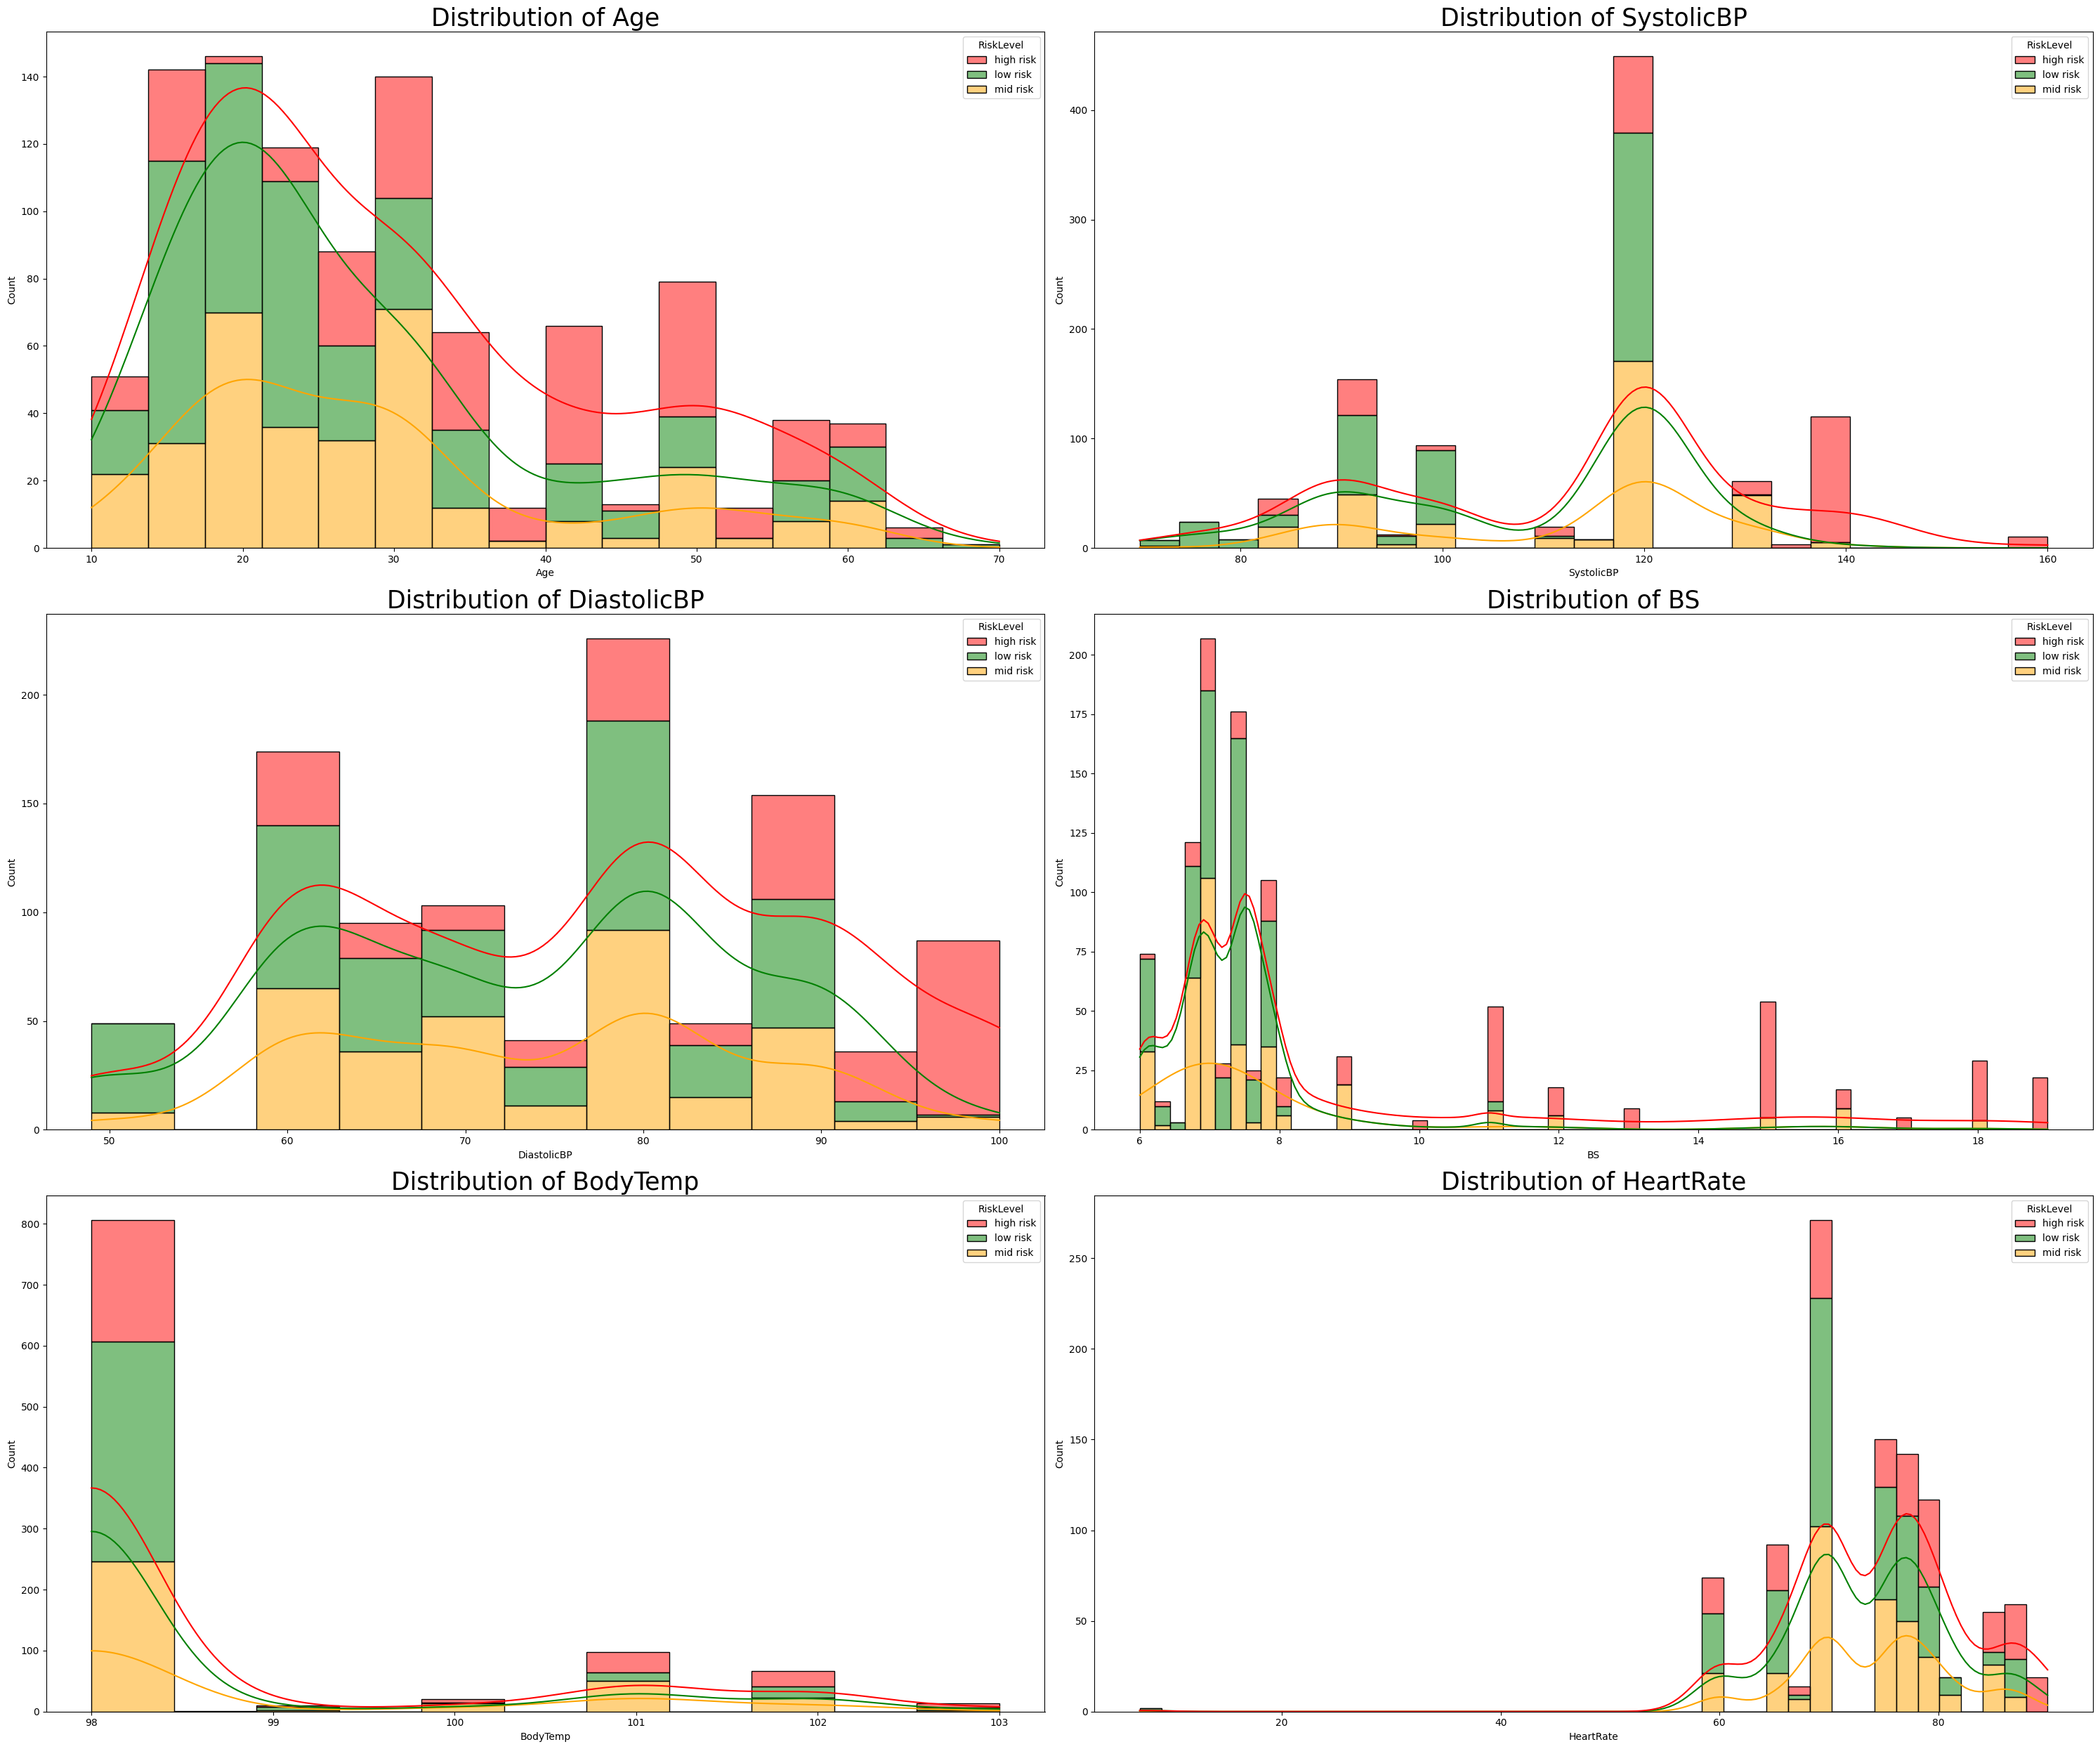

In [11]:
# Plotting a histogram for the feature variables
fig, axes = plt.subplots(ncols=2, nrows=3, figsize=(30, 25))
for ax, col in zip(axes.flatten(), m_df.columns[:-1]):
    sns.histplot(data=m_df, x=col, ax=ax, kde=True, hue="RiskLevel", palette={"low risk": "green", "mid risk": "orange", "high risk": "red"}, multiple="stack", element="bars", hue_order=m_df.RiskLevel.unique().tolist())
    ax.set_title(f"Distribution of {col}", fontsize=25)
plt.tight_layout()
plt.show()

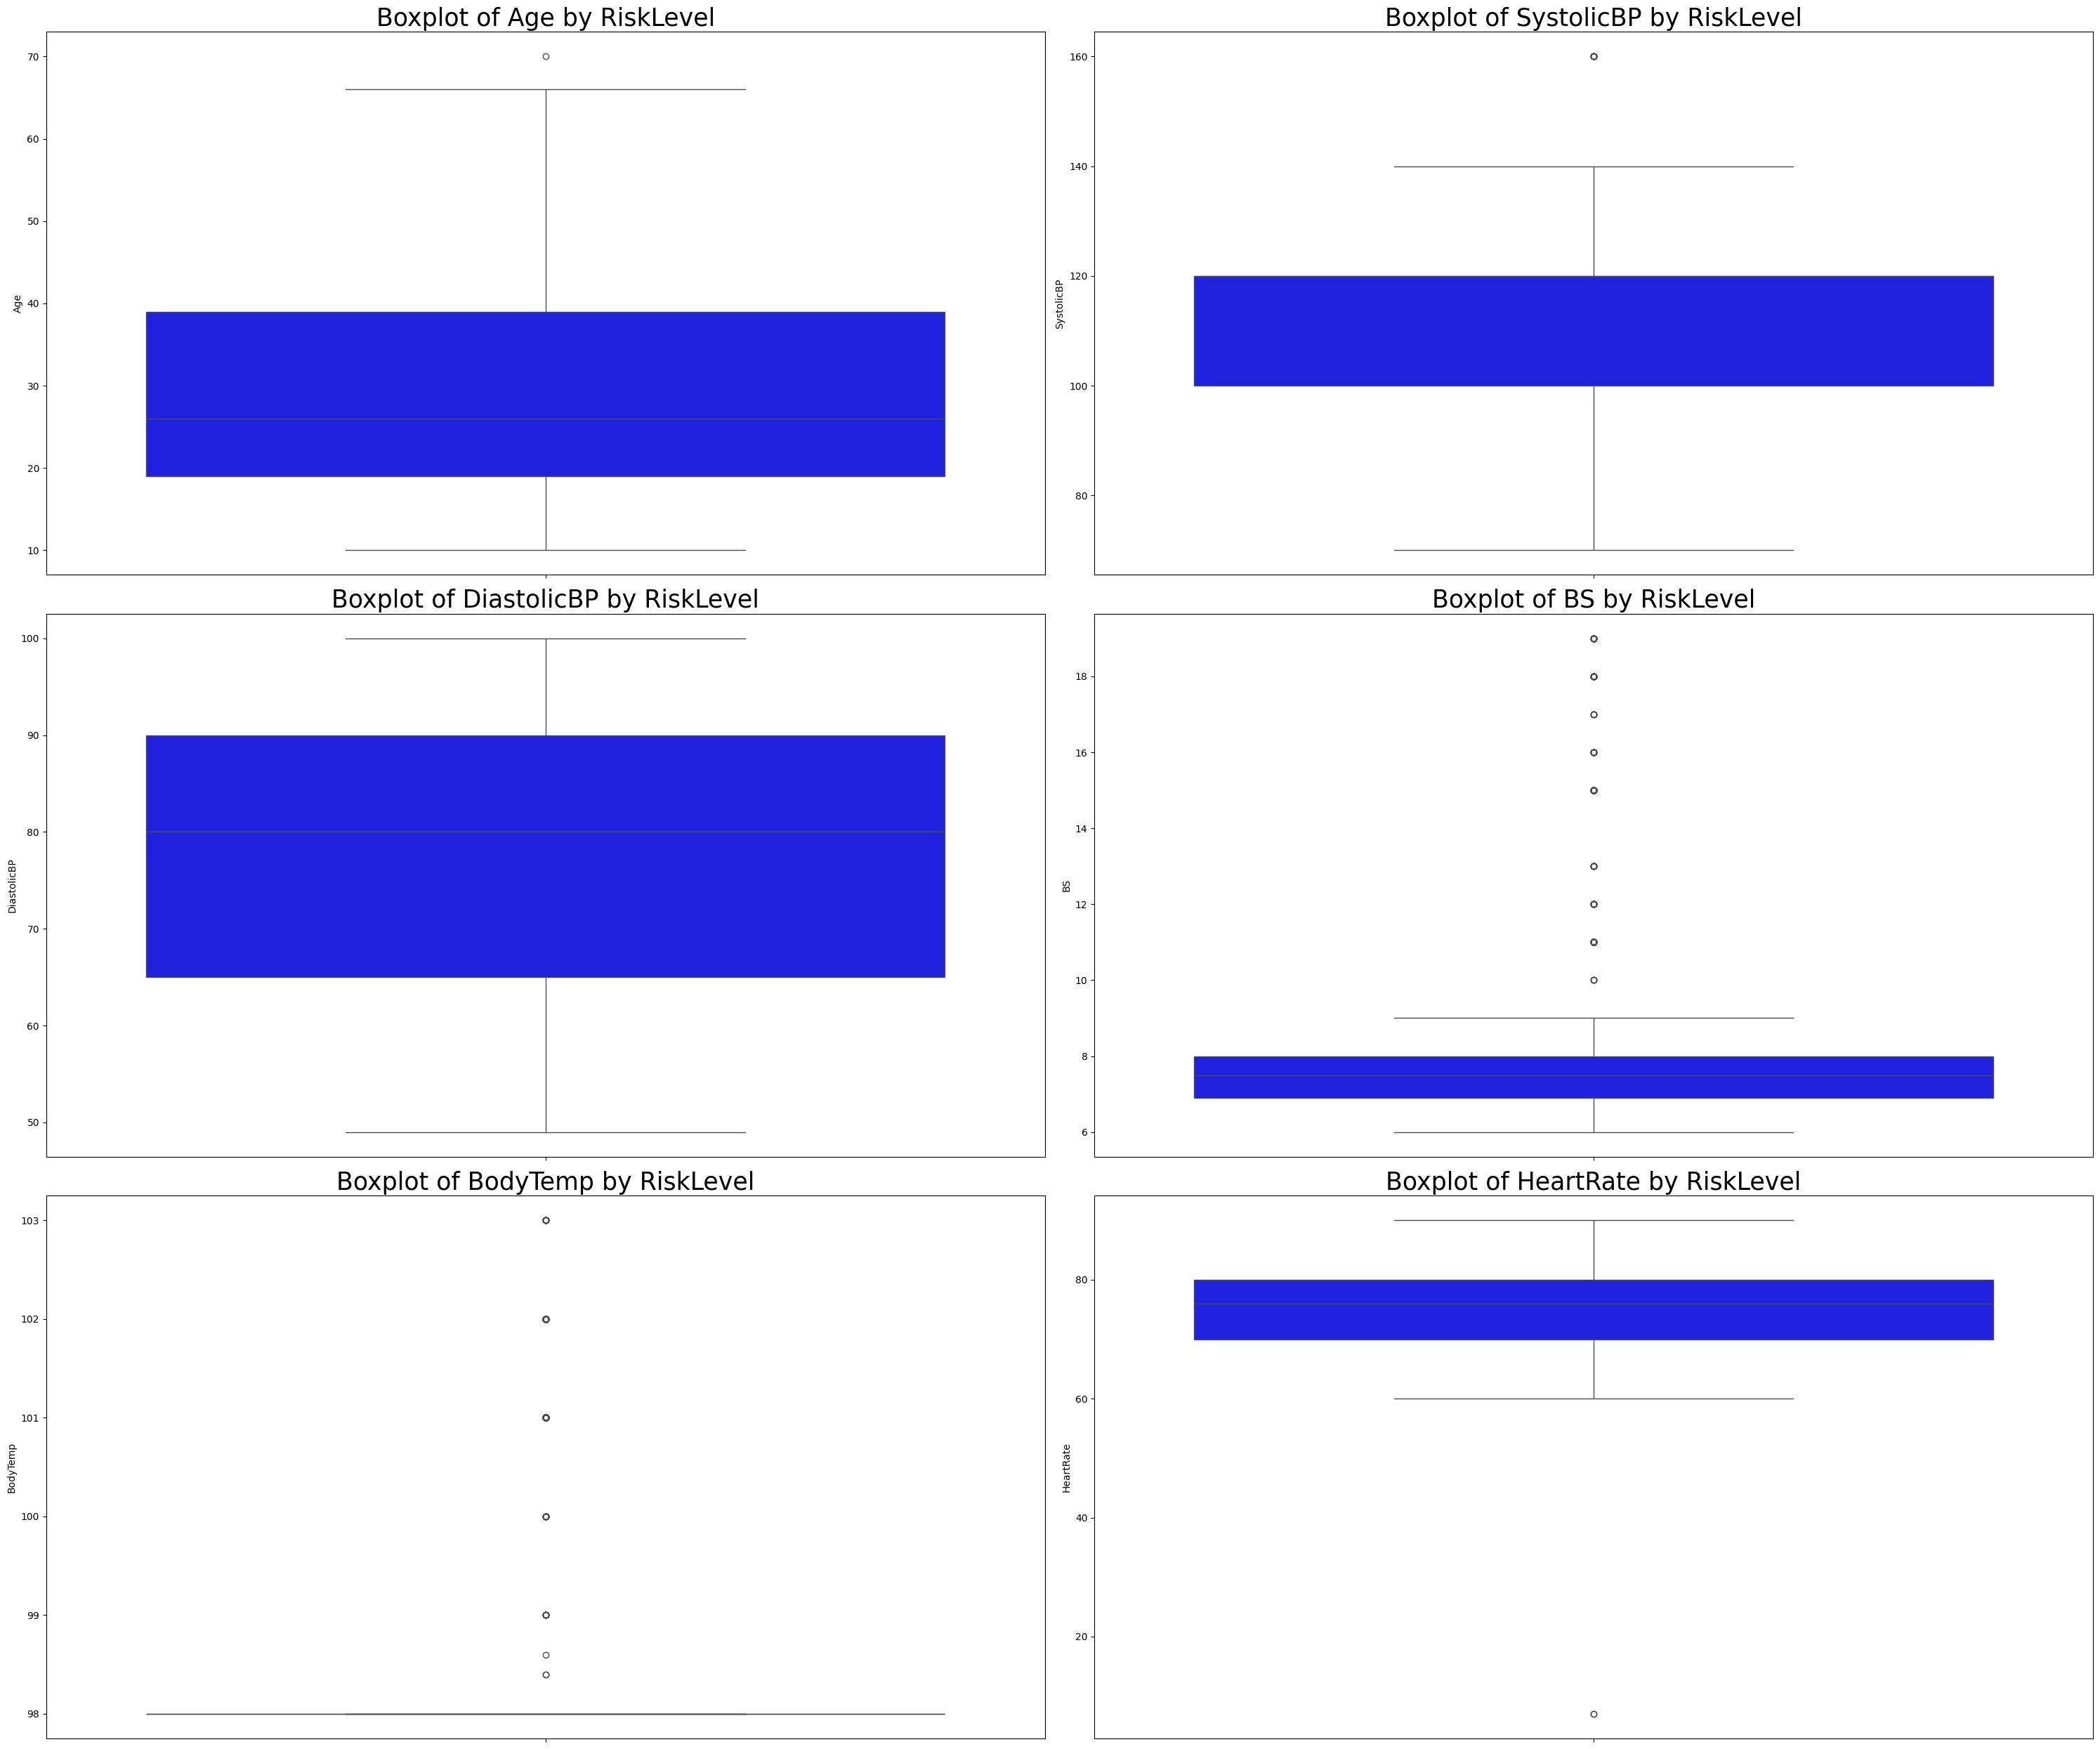

In [ ]:
# Plotting boxplots for the feature variables
fig, axes = plt.subplots(ncols=2, nrows=3, figsize=(30, 25))
for ax, col in zip(axes.flatten(), m_df.columns[:-1]):
    sns.boxplot(y=m_df[col], ax=ax, color="blue")
    ax.set_title(f"Boxplot of {col} by RiskLevel", fontsize=25)
    
plt.tight_layout()
plt.show()

**Correlation Analysis of variables**

In [18]:
# Converting the target variable into numerical values using Label Encoding
label_encoder = LabelEncoder()
m_df["RiskLevel"] = label_encoder.fit_transform(m_df["RiskLevel"])
m_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   int64  
dtypes: float64(2), int64(5)
memory usage: 55.6 KB


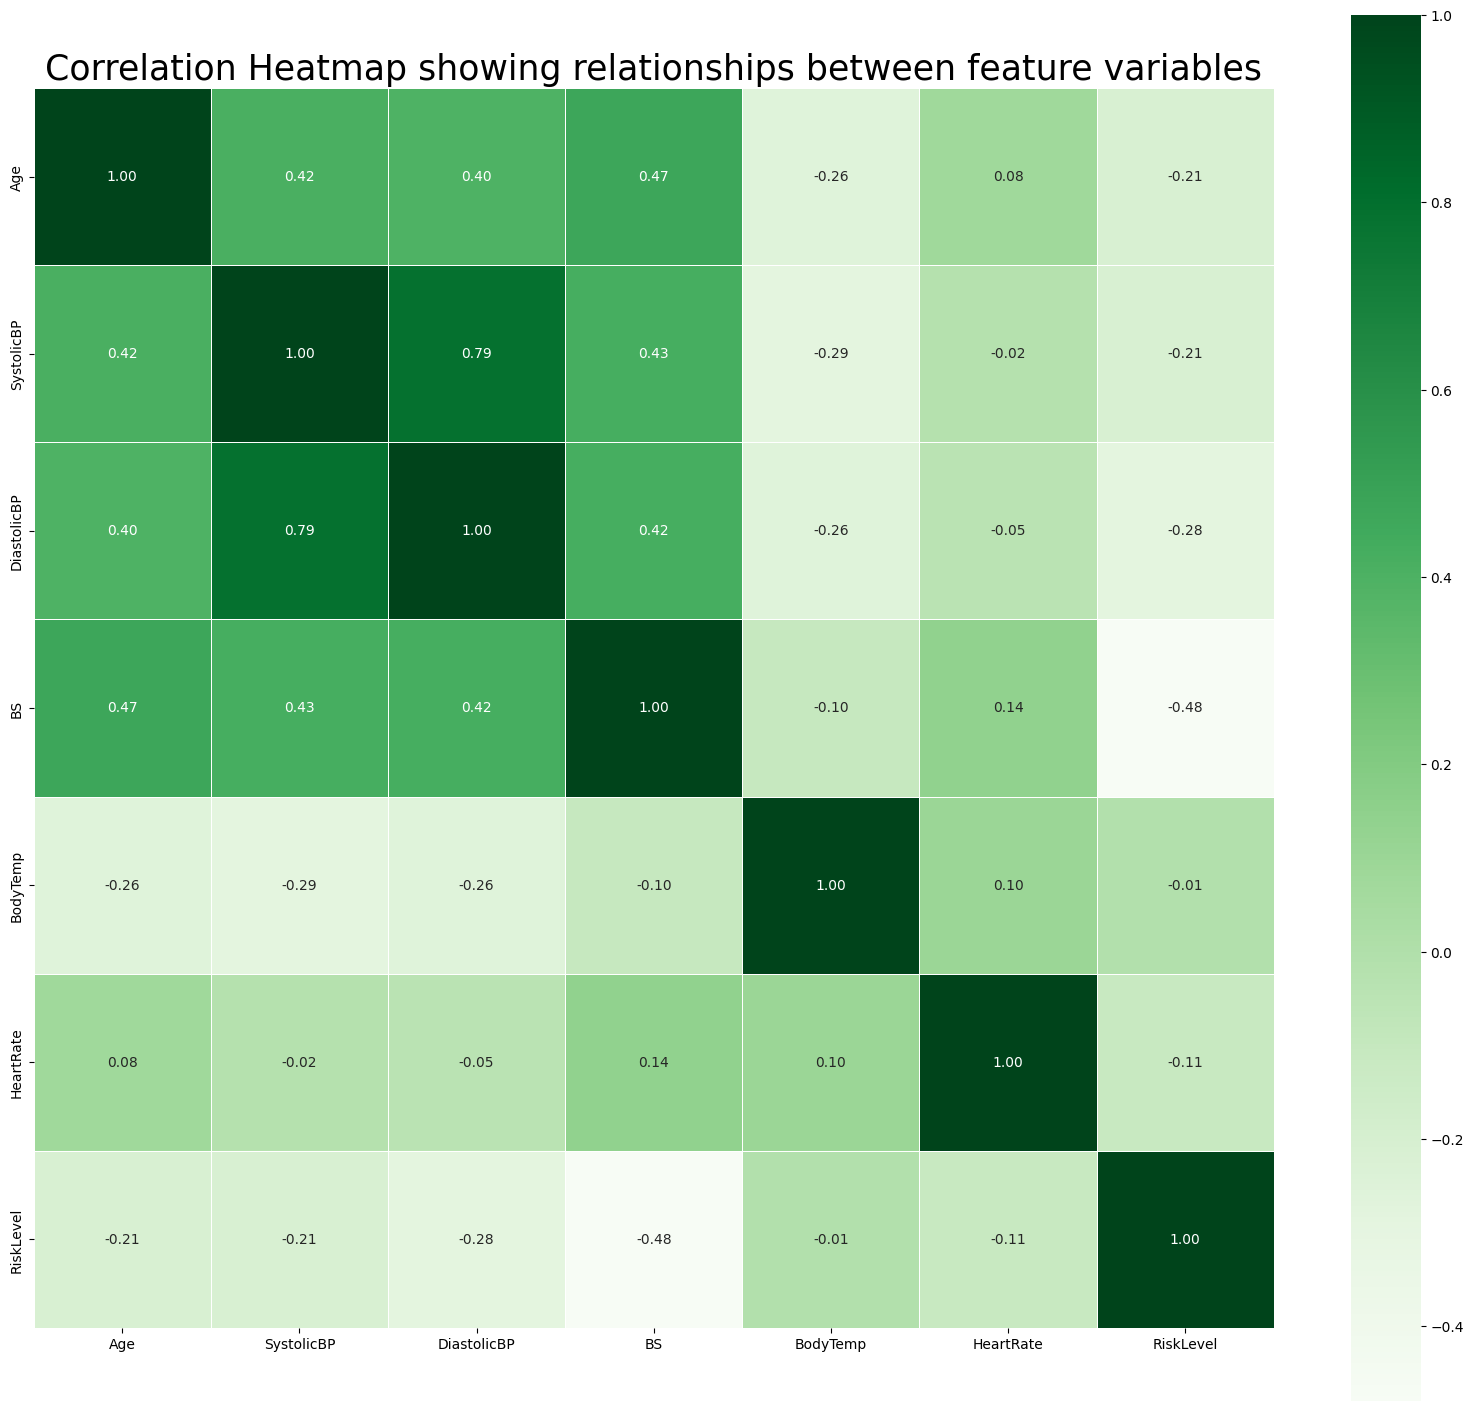

In [19]:
# Creating a correlation heatmap to check for multicollinearity among the feature variables
correlation_matrix = m_df.corr()
plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, annot=True, cbar=True, square=True, fmt=".2f", cmap="Greens", linewidths=0.5)
plt.title("Correlation Heatmap showing relationships between feature variables", fontsize=25)
plt.show()

In [22]:
corr_pairs = correlation_matrix.unstack()
corr_pairs

Age          Age            1.000000
             SystolicBP     0.416045
             DiastolicBP    0.398026
             BS             0.473284
             BodyTemp      -0.255323
             HeartRate      0.079798
             RiskLevel     -0.211851
SystolicBP   Age            0.416045
             SystolicBP     1.000000
             DiastolicBP    0.787006
             BS             0.425172
             BodyTemp      -0.286616
             HeartRate     -0.023108
             RiskLevel     -0.208797
DiastolicBP  Age            0.398026
             SystolicBP     0.787006
             DiastolicBP    1.000000
             BS             0.423824
             BodyTemp      -0.257538
             HeartRate     -0.046151
             RiskLevel     -0.284633
BS           Age            0.473284
             SystolicBP     0.425172
             DiastolicBP    0.423824
             BS             1.000000
             BodyTemp      -0.103493
             HeartRate      0.142867
 

In [33]:
# Getting the highly correlated feature pairs with a correlation coefficient greater than 0.8 
# high_corr_pairs = corr_pairs[(abs(corr_pairs) > 0.8)]
# high_corr_pairs.index.get_level_values(0)

In [35]:
# Dealing with multicollinearity
# Calculating the Variance Inflation Factor (VIF) for each feature variable
X = m_df[["SystolicBP", "DiastolicBP"]]
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data

,Variable,VIF
0,SystolicBP,79.96833
1,DiastolicBP,79.96833
